In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
from pathlib import Path
import re
import json
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def parse_single_file_with_offset(file_path, round_offset):
    """
    Parses a single training log file, applying a round offset to all round numbers.

    Args:
        file_path: The path to the training results text file.
        round_offset: The number to add to each extracted round number.

    Returns:
        A tuple containing two lists: (train_loss_list, evaluation_metrics_list).
    """
    print(f"-> Processing file: {file_path} with offset: {round_offset}")

    try:
        with open(file_path, 'r') as f:
            content = f.read()
    except FileNotFoundError:
        print(f"   Error: File not found at {file_path}. Skipping.")
        return [], []

    # --- 1. Extract Training Loss ---
    train_loss_per_round = []

    # Pattern to find 'Aggregated ClientApp-side Train Metrics' block
    train_loss_block_match = re.search(
        r"Aggregated ClientApp-side Train Metrics:\s*({.*?})\s*"+
        "Aggregated ClientApp-side Evaluate Metrics:",
        content,
        re.DOTALL
    )

    if train_loss_block_match:
      train_loss_content = train_loss_block_match.group(1)

      # PATTERN:
      # Group 1: Round Number
      # Group 2: train_loss value
      # Group 3: train_loss_pre value (Optional)
      train_loss_pattern = re.compile(
          r"(\d+):\s*\{\s*'train_loss':\s*'([0-9\.\+-e]+)'(?:,\s*'train_loss_pre':\s*'([0-9\.\+-e]+)')?"
      )

      for match in train_loss_pattern.finditer(train_loss_content):
          # Parse Round Number
          original_round_num = int(match.group(1))
          new_round_num = original_round_num + round_offset

          # Parse train_loss
          train_loss_str = match.group(2)
          try:
              train_loss_value = float(train_loss_str)
          except (ValueError, TypeError):
              train_loss_value = None

          # Create the entry dictionary
          entry = {
              "round": new_round_num,
              "train_loss": train_loss_value
          }

          # Check for Optional train_loss_pre (Group 3)
          # match.group(3) will be None if the pattern wasn't found
          if match.group(3):
              try:
                  train_loss_pre_value = float(match.group(3))
                  entry["train_loss_pre"] = train_loss_pre_value
              except (ValueError, TypeError):
                  pass # or handle error

          train_loss_per_round.append(entry)

    # --- 2. Extract Evaluation Metrics ---
    evaluation_metrics_per_round = []

    # Pattern to find 'ServerApp-side Evaluate Metrics' block
    eval_metrics_block_match = re.search(
        r"ServerApp-side Evaluate Metrics:\s*({.*?})\s*$",
        content,
        re.DOTALL
    )

    if eval_metrics_block_match:
        eval_metrics_content = eval_metrics_block_match.group(1)
        # Pattern to find a single round's metrics block
        eval_round_pattern = re.compile(
            r"(\d+):\s*\{\s*(.*?)\s*\}",
            re.DOTALL
        )

        # Pattern to find individual metrics (Key: 'Value') within the round block
        metric_key_value_pattern = re.compile(
            r"'([^']+?)':\s*'([0-9\.\+-e]+)'"
        )

        for round_match in eval_round_pattern.finditer(eval_metrics_content):
            # Apply the offset here
            original_round_num = int(round_match.group(1))
            new_round_num = original_round_num + round_offset
            metrics_block = round_match.group(2)

            round_data = {"round": new_round_num}

            for metric_match in metric_key_value_pattern.finditer(metrics_block):
                metric_name = metric_match.group(1)
                metric_value_str = metric_match.group(2)

                try:
                    round_data[metric_name] = float(metric_value_str)
                except ValueError:
                    round_data[metric_name] = None

            # Only add if the round has actual metrics (and skip round 0 if present)
            if new_round_num > round_offset and len(round_data) > 1:
                evaluation_metrics_per_round.append(round_data)

    return train_loss_per_round, evaluation_metrics_per_round

In [11]:
# combine results of partial experiments
def combine_results_file(experiment_path, OUTPUT_JSON_FILE):
  all_train_loss = []
  all_eval_metrics = []
  current_round_offset = 0

  print("--- Starting Multi-File Processing ---")
  # sort folders based on there number
  experiments = [dir for dir in os.listdir(experiment_path) if dir.isnumeric()]
  sorted_experiments = sorted(experiments, key=int)
  print(sorted_experiments)
  for partial_experiment in sorted_experiments:
      file_name = "/".join(
          [experiment_path, partial_experiment, "server_results.txt"])

      # Get data from the current file
      train_loss_data, eval_metrics_data = parse_single_file_with_offset(
          file_name, current_round_offset)

      # Append data to the master lists
      all_train_loss.extend(train_loss_data)
      all_eval_metrics.extend(eval_metrics_data)

      # Update the offset for the next file
      if train_loss_data:
          # Use the number of train loss entries as the offset increment
          current_round_offset += len(train_loss_data)
      else:
          print("   No valid train loss data found, offset remains unchanged.")

  # Create the final JSON structure
  final_data = {
      "train_loss_per_round": all_train_loss,
      "evaluation_metrics_per_round": all_eval_metrics
  }

  # Write the combined data to the output JSON file
  try:
      with open(OUTPUT_JSON_FILE, 'w') as json_file:
          json.dump(final_data, json_file, indent=2)

      print("--- Process Complete ---")
      print(f"   Total rounds: {current_round_offset}")
      print(f"   Output saved to '{OUTPUT_JSON_FILE}'")

  except Exception as e:
      print(f"\n Failed to write output JSON: {e}")


In [12]:
# Load the combined_server_results JSON data

# PLOT 1: Train Loss
def plot_train_val_loss(combined_server_results_path,
                        plot_output_folder_name='/content'):
  with open(combined_server_results_path, 'r') as f:
      data = json.load(f)

  # Convert the lists under the keys to DataFrames
  train_df = pd.DataFrame(data['train_loss_per_round'])
  val_df = pd.DataFrame(data['evaluation_metrics_per_round'])

  # Merge the dataframes on 'round' for plotting of train_loss and val_loss
  merged_df = pd.merge(train_df, val_df, on='round')

  plt.figure(figsize=(10, 6))

  train_loss_key = 'train_loss_pre' if 'train_loss_pre' in merged_df else 'train_loss'
  plt.plot(merged_df['round'], merged_df[train_loss_key],
           label='Train Loss', color='blue')
  plt.plot(merged_df['round'], val_df['val_loss'],
           label='Val Loss', color='orange')

  plt.title('Train and Val Loss', fontweight='bold')
  plt.xlabel('Round Number')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.tight_layout()
  print(f"\tSaving Train loss plot in {plot_output_folder_name}/Train_val_loss.png")
  plt.savefig(plot_output_folder_name + '/Train_loss.png')

In [13]:
# PLOT 2: metrics (mIoU, fw_mIoU, F1_Score)
def plot_metrics(combined_server_results_path,
                       metric= 'mIoU',color = 'green',
                       plot_output_folder_name='/content'):

  with open(combined_server_results_path, 'r') as f:
      data = json.load(f)

  # Convert the lists under the keys to DataFrames
  train_df = pd.DataFrame(data['train_loss_per_round'])
  val_df = pd.DataFrame(data['evaluation_metrics_per_round'])

  # Merge the dataframes on 'round' for plotting of train_loss and val_loss
  merged_df = pd.merge(train_df, val_df, on='round')

  # Find the round with the best mIoU
  best_metric_row = val_df.loc[val_df[metric].idxmax()]
  best_metric_round = best_metric_row['round']
  best_metric_value = best_metric_row[metric]

  plt.figure(figsize=(10, 6))
  plt.plot(val_df['round'], val_df[metric], label=metric, color=color)

  # Mark the best mIoU with an 'X'
  plt.scatter(best_metric_round, best_metric_value, marker='x',
              color='black', s=100, zorder=5,
              label=f'Best {metric} (Round {best_metric_round:.0f})={best_metric_value:0.4f}')

  plt.title(metric, fontweight='bold')
  plt.xlabel('Rounds')
  plt.ylabel(metric)
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.tight_layout()
  print(f"\tSaving {metric} plot in {plot_output_folder_name}/val_{metric}.png")
  plt.savefig(plot_output_folder_name + "/val_" + metric+ ".png")


======Experiment: (FedAvg, IID_Partition)======
--- Starting Multi-File Processing ---
['30', '60', '90', '120', '150', '180']
-> Processing file: /content/drive/MyDrive/Simulations/New Partition Test (4th)/IID_Partition/FedAvg/30/server_results.txt with offset: 0
-> Processing file: /content/drive/MyDrive/Simulations/New Partition Test (4th)/IID_Partition/FedAvg/60/server_results.txt with offset: 30
-> Processing file: /content/drive/MyDrive/Simulations/New Partition Test (4th)/IID_Partition/FedAvg/90/server_results.txt with offset: 60
-> Processing file: /content/drive/MyDrive/Simulations/New Partition Test (4th)/IID_Partition/FedAvg/120/server_results.txt with offset: 90
-> Processing file: /content/drive/MyDrive/Simulations/New Partition Test (4th)/IID_Partition/FedAvg/150/server_results.txt with offset: 120
-> Processing file: /content/drive/MyDrive/Simulations/New Partition Test (4th)/IID_Partition/FedAvg/180/server_results.txt with offset: 150
--- Process Complete ---
   Total 

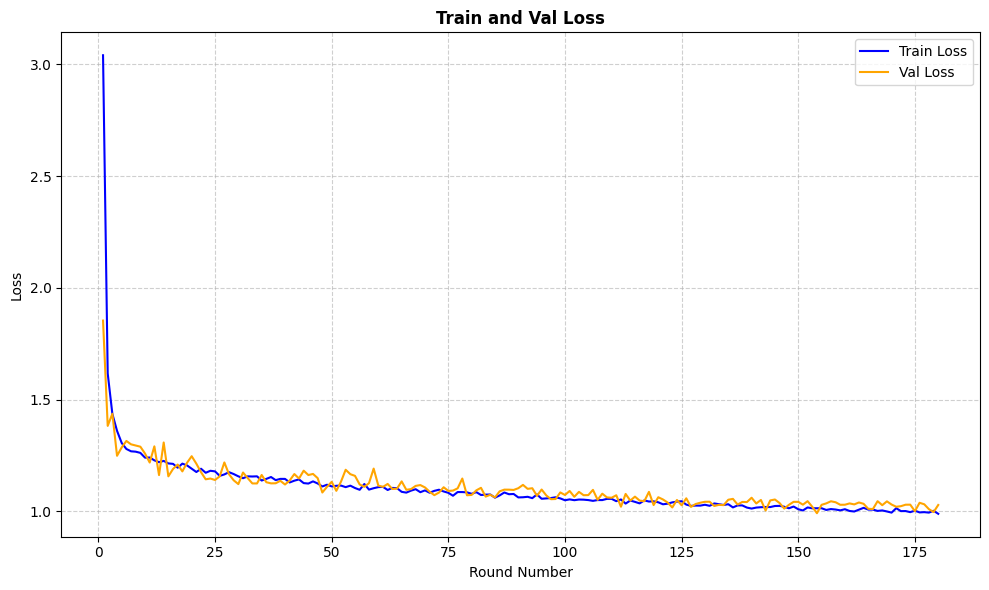

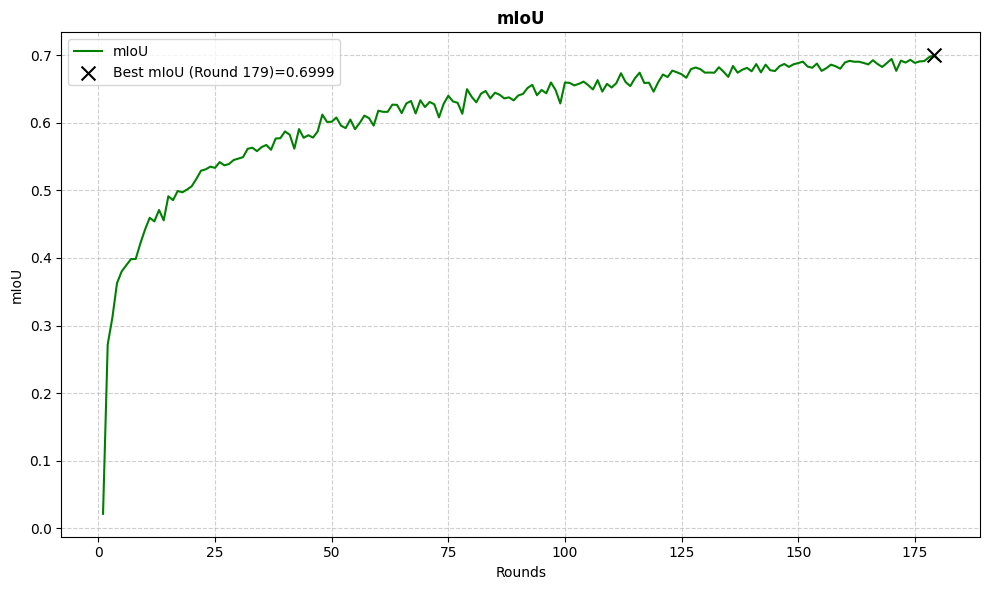

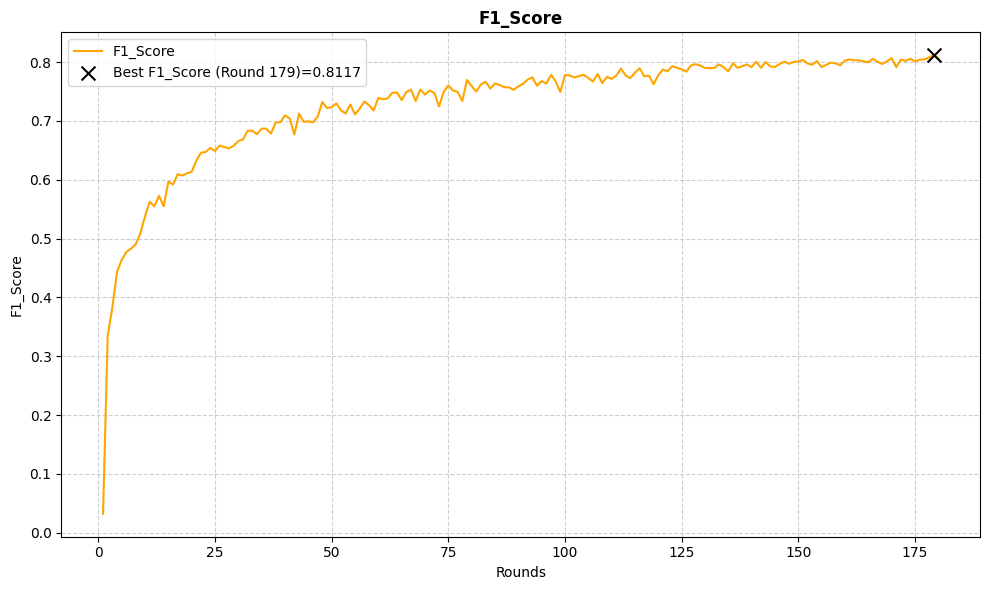

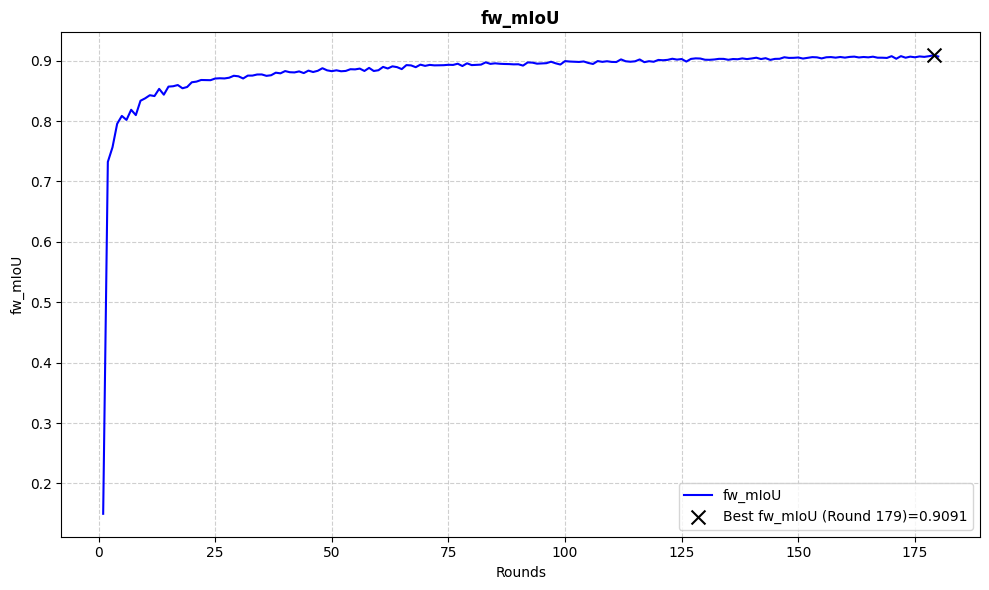

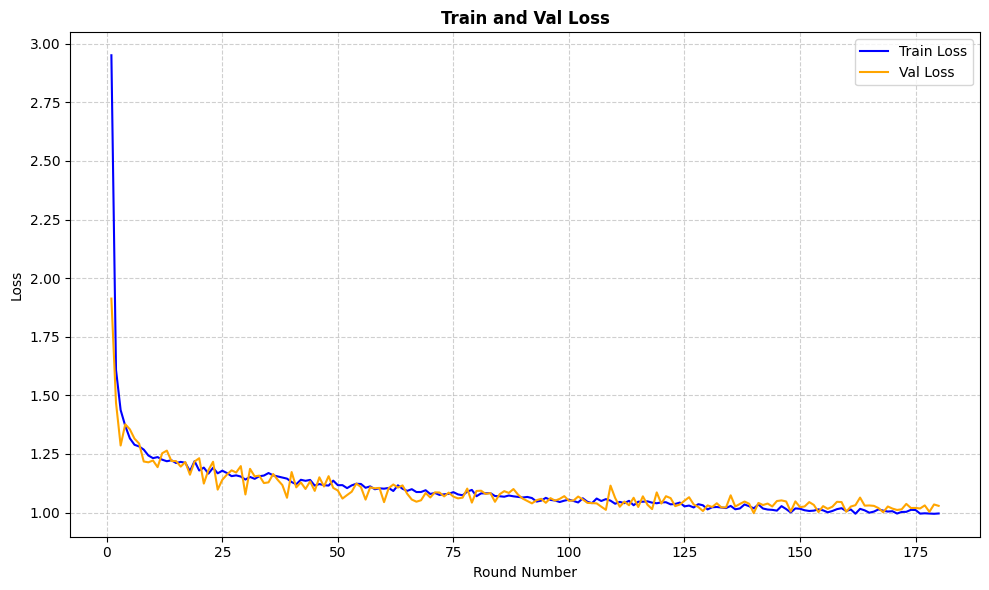

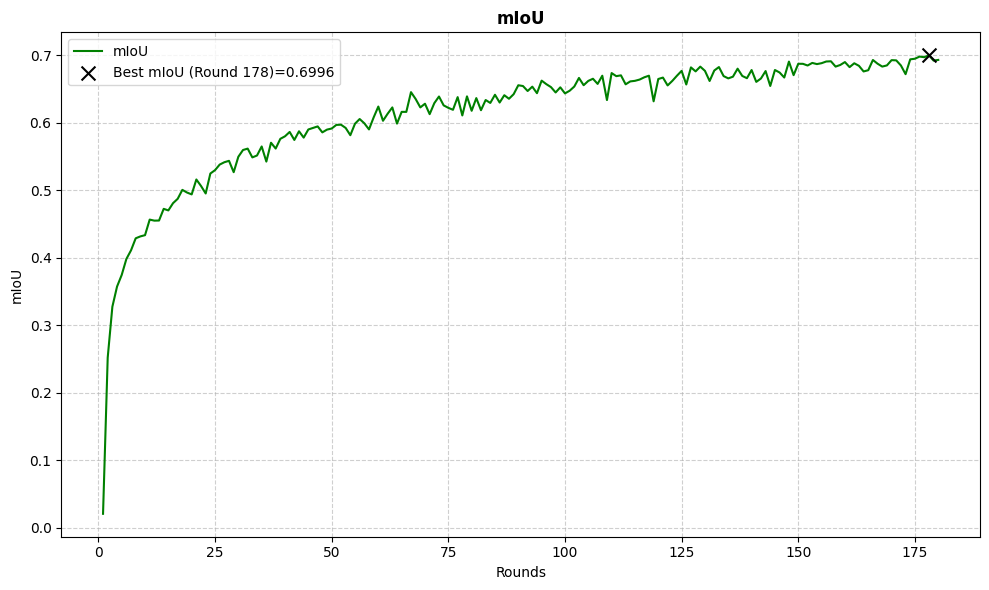

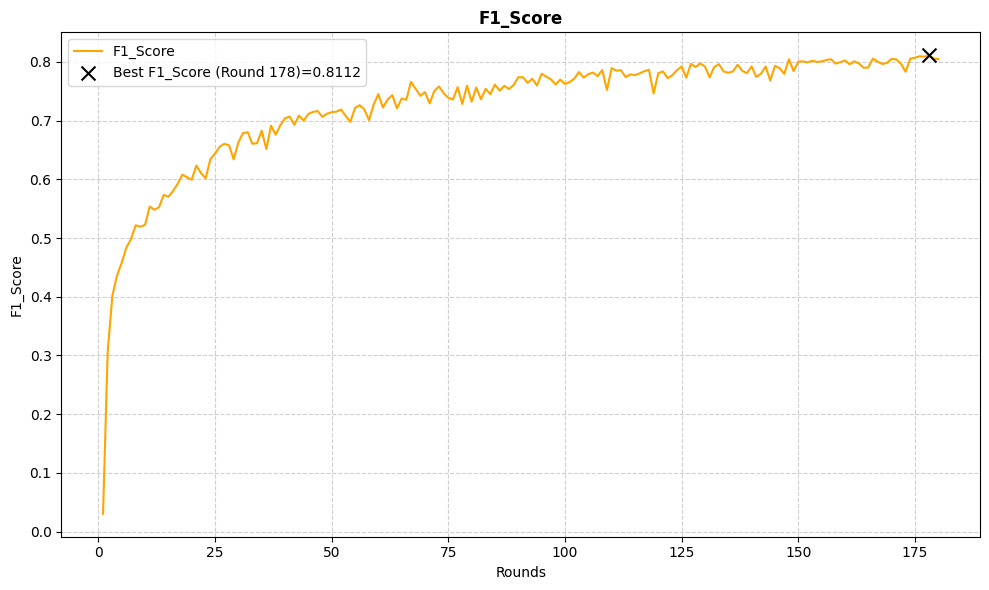

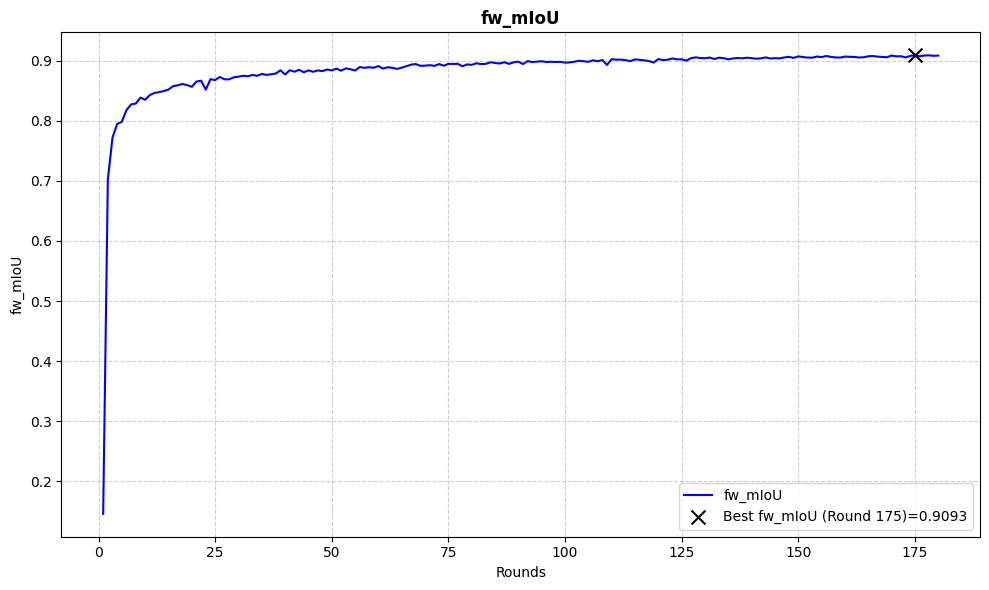

In [15]:
# run this cell to generate plots to experiments defined by
# {trial_num, partitions, aggegators}

# partation: City_Partitions,
#             IID_Partition, Non_IID_Partition
#             Per_City_IID, Per_City_Non_IID
partitions = ["IID_Partition",
              "Non_IID_Partition"]

# aggegator: FedAvg, FedProx
aggregators = ["FedAvg"]

# Trial number : First, Second, Third
trial_num = "New Partition Test (4th)"

for partition in partitions:
  for aggregator in aggregators:
    print(f"\n======Experiment: ({aggregator}, {partition})======")
    experiment_path = f"/content/drive/MyDrive/Simulations/" \
                      f"{trial_num}/{partition}/{aggregator}"

    output_json = "/combined_server_results.json"

    plot_output_folder_name = experiment_path + '/plots'
    plot_output_folder_path = Path(plot_output_folder_name)
    try:
      plot_output_folder_path.mkdir(parents=False, exist_ok=True)
    except FileNotFoundError:
      continue

    combined_server_results_path = plot_output_folder_name + output_json


    metrics = ["mIoU", 'F1_Score', 'fw_mIoU'] # mIoU, F1_Score, fw_mIoU
    colors = ['green', 'orange', 'blue']

    combine_results_file(experiment_path, combined_server_results_path)

    plot_train_val_loss(combined_server_results_path, plot_output_folder_name)

    for metric, color in zip(metrics, colors):
      plot_metrics(combined_server_results_path,
                  metric, color, plot_output_folder_name)


In [16]:
def plot_aggregator_comparison(partition_name, aggregator_paths, metric_name,
                               trial_num,base_dir='/content/drive/MyDrive/Simulations'):
    """
    Reads JSON results for multiple aggregators in a specific partition
    and plots them on a single graph.

    Args:
        partition_name (str): The partition folder name ('City_Partitions').
        aggregator_paths (list): List of relative paths for aggregators
        (['FedAvg/new', 'FedProx/0.05_new']).
        metric_name (str): The key of the metric to plot ('mIoU', 'F1_Score').
        base_dir (str): Root directory where simulations are stored.
    """

    plt.figure(figsize=(12, 7))

    # Store data availability to avoid showing empty plots
    has_data = False
    # update the base_dir
    base_dir = os.path.join(base_dir, trial_num, partition_name)

    for agg_path in aggregator_paths:
        # Construct full path to the JSON file
        # Structure: /Partition/Aggregator/plots/combined_server_results.json
        json_file_path = os.path.join(base_dir, agg_path,
                                      'plots', 'combined_server_results.json')

        if not os.path.exists(json_file_path):
            print(f"  [Warning] File not found: {json_file_path}")
            continue

        try:
            with open(json_file_path, 'r') as f:
                data = json.load(f)

            rounds = []
            values = []

            data_list = data.get('evaluation_metrics_per_round', [])
            for entry in data_list:
                # Ensure metric exists in this round's dictionary
                if entry.get(metric_name) is not None:
                    rounds.append(entry['round'])
                    values.append(entry[metric_name])

            # Plot if data was found
            if rounds and values:
                has_data = True
                # Mark the maximum value
                max_val = max(values)
                max_round = rounds[values.index(max_val)]

                # ("FedProx/0.05_new"->"FedProx-400 rounds")
                label_name = f"{agg_path.split('/')[0]}--Best {metric_name}({max_round} rounds)={max_val}"

                plt.plot(rounds, values, label=label_name, linewidth=2)
                plt.scatter(max_round, max_val, s=100, zorder=5,
                            marker='x', color='black')

        except Exception as e:
            print(f"  [Error] Could not read {agg_path}: {e}")

    if has_data:
        plt.title(f'{metric_name} Comparison: {partition_name}',
                  fontsize=14, fontweight='bold')
        plt.xlabel('Rounds', fontsize=12)
        plt.ylabel(metric_name, fontsize=12)
        plt.legend(title='Aggregator', fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()

        # create dir "combined plots" if not existed
        plot_folder_name = base_dir + '/combined plots'
        plot_folder_path = Path(plot_folder_name)

        try:
          plot_folder_path.mkdir(parents=False, exist_ok=True)
        except FileNotFoundError:
            print(f"Error {partition_name} not Found ")
        plt.savefig(plot_folder_name + "/combined_val_" + metric_name + ".png")
    else:
        plt.close()
        print(f"-> No valid data found for partition: {partition_name}")

Generating comparison plots for metric: mIoU...

Processing Partition: IID_Partition
------------------------------
Processing Partition: Non_IID_Partition
------------------------------
Generating comparison plots for metric: F1_Score...

Processing Partition: IID_Partition
------------------------------
Processing Partition: Non_IID_Partition
------------------------------
Generating comparison plots for metric: fw_mIoU...

Processing Partition: IID_Partition
------------------------------
Processing Partition: Non_IID_Partition
------------------------------


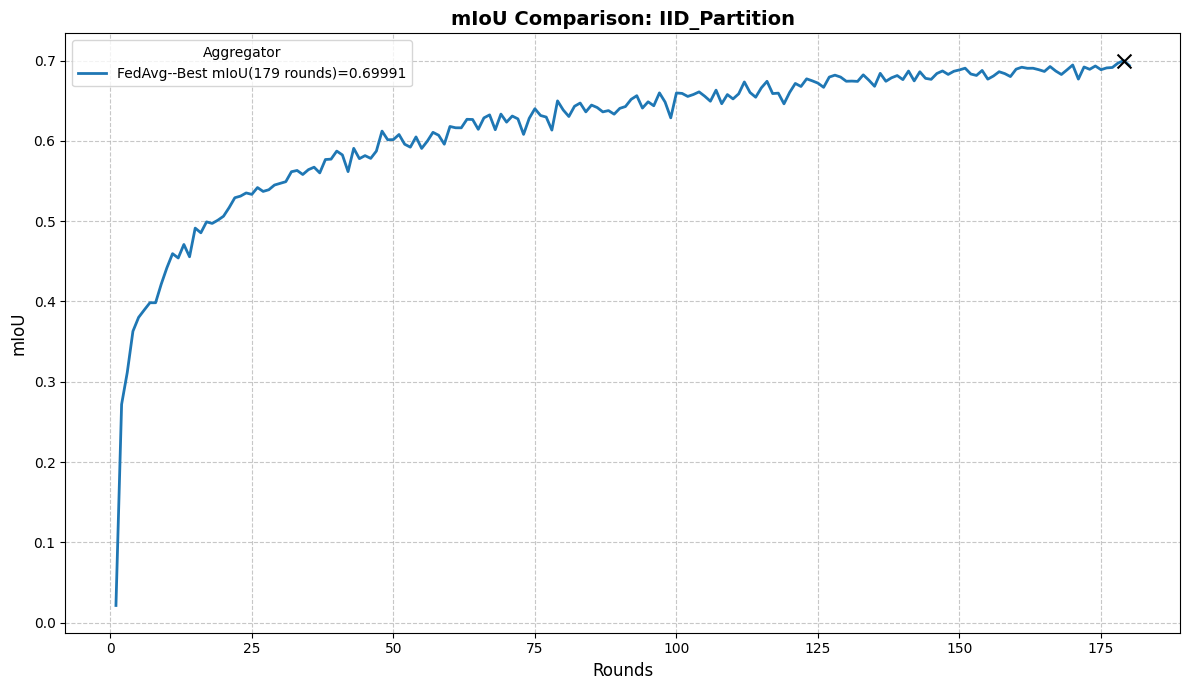

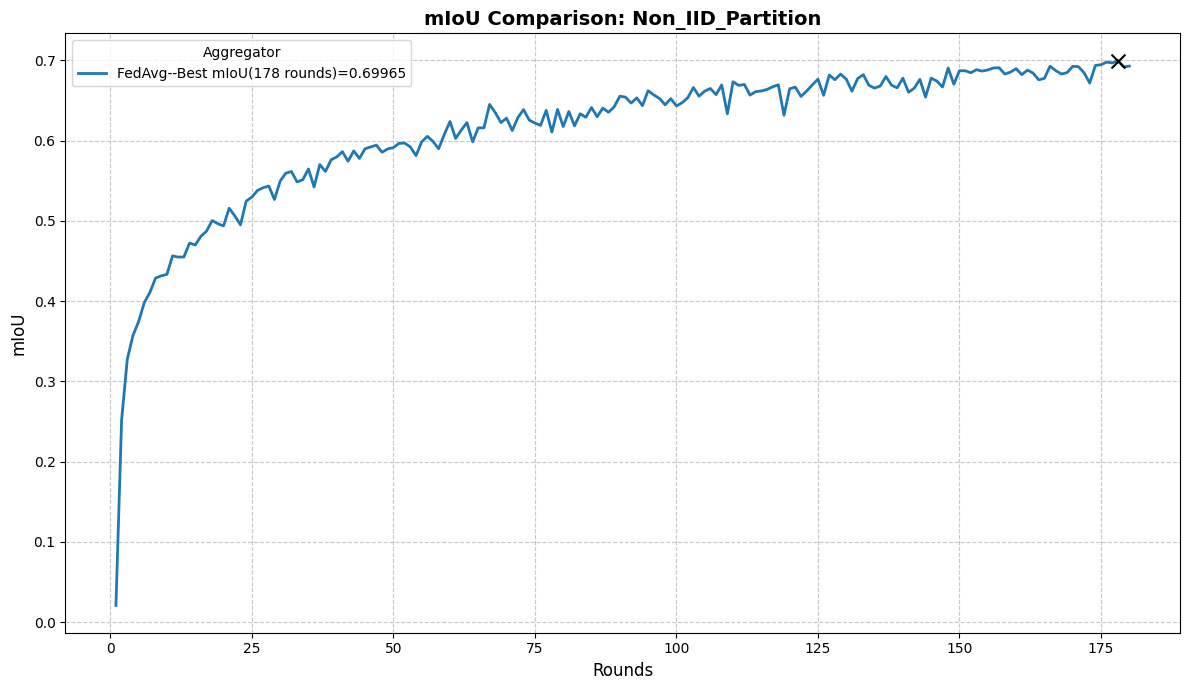

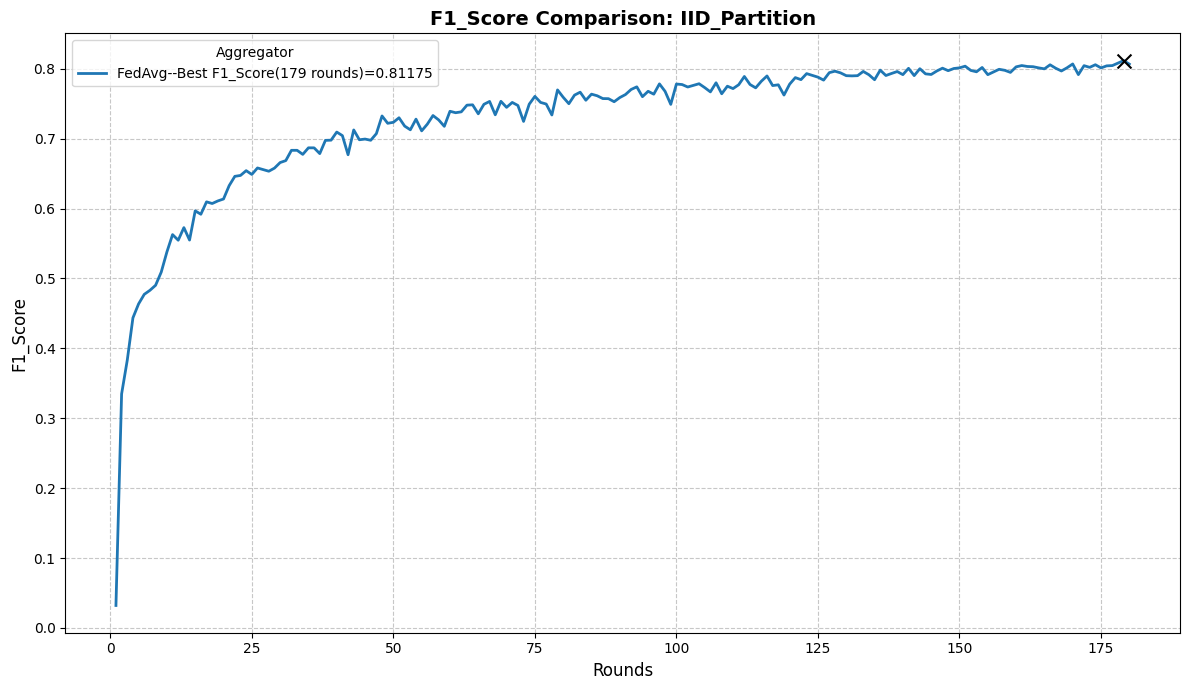

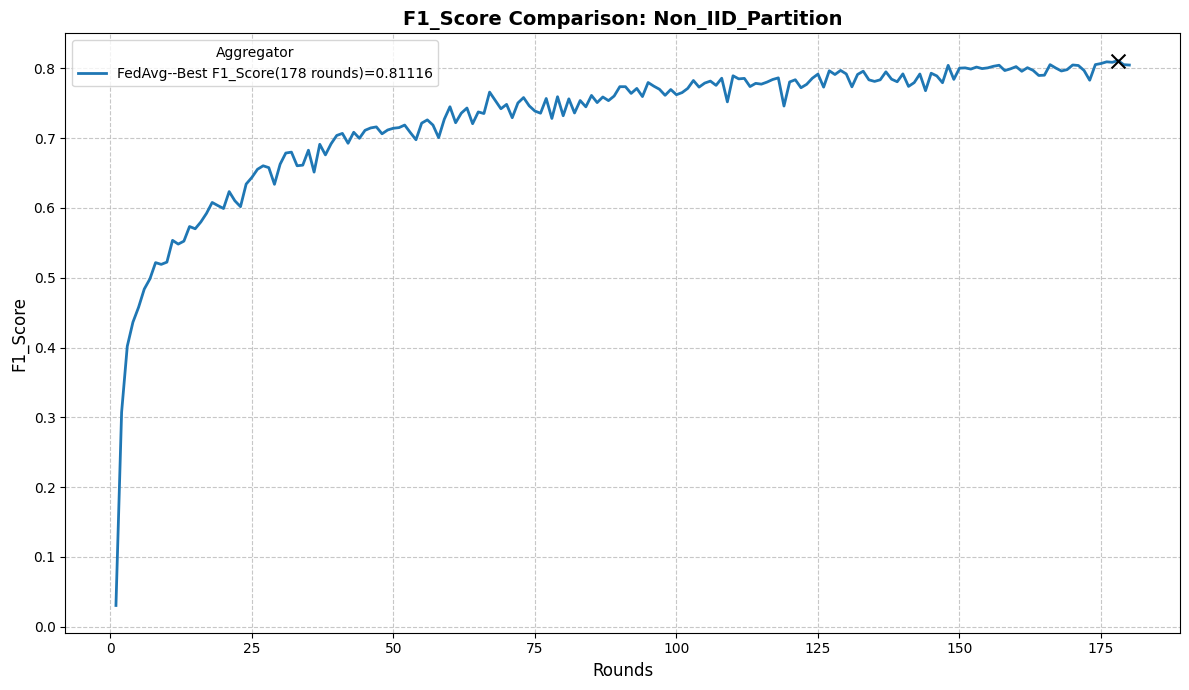

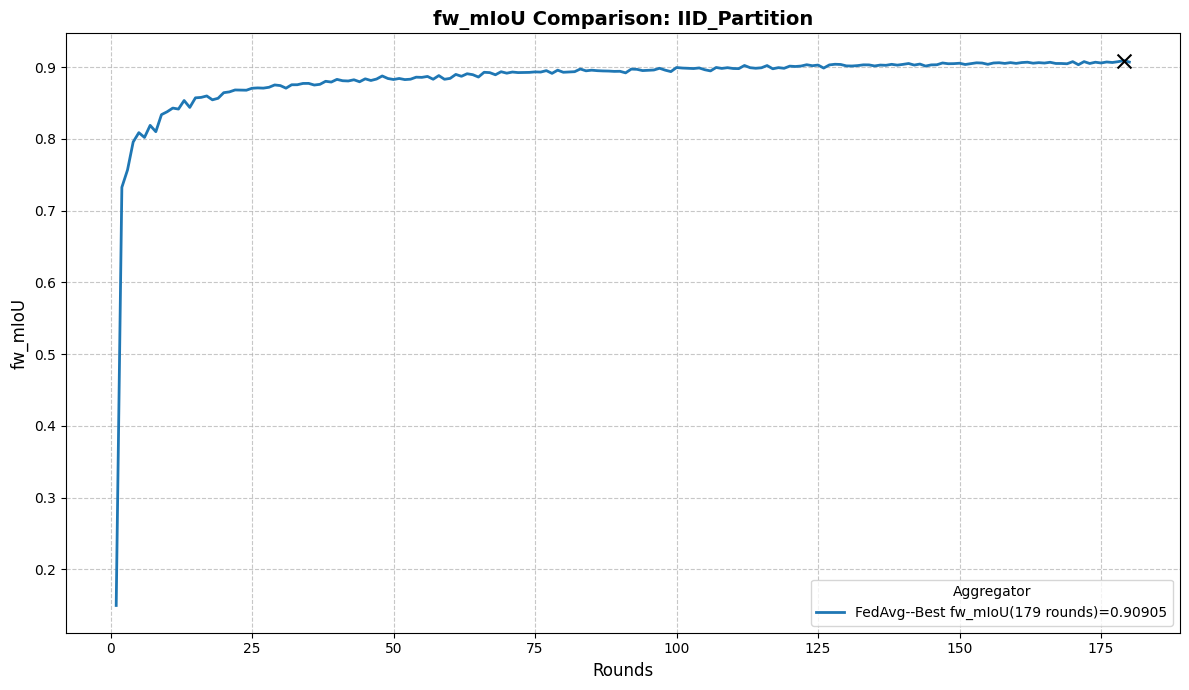

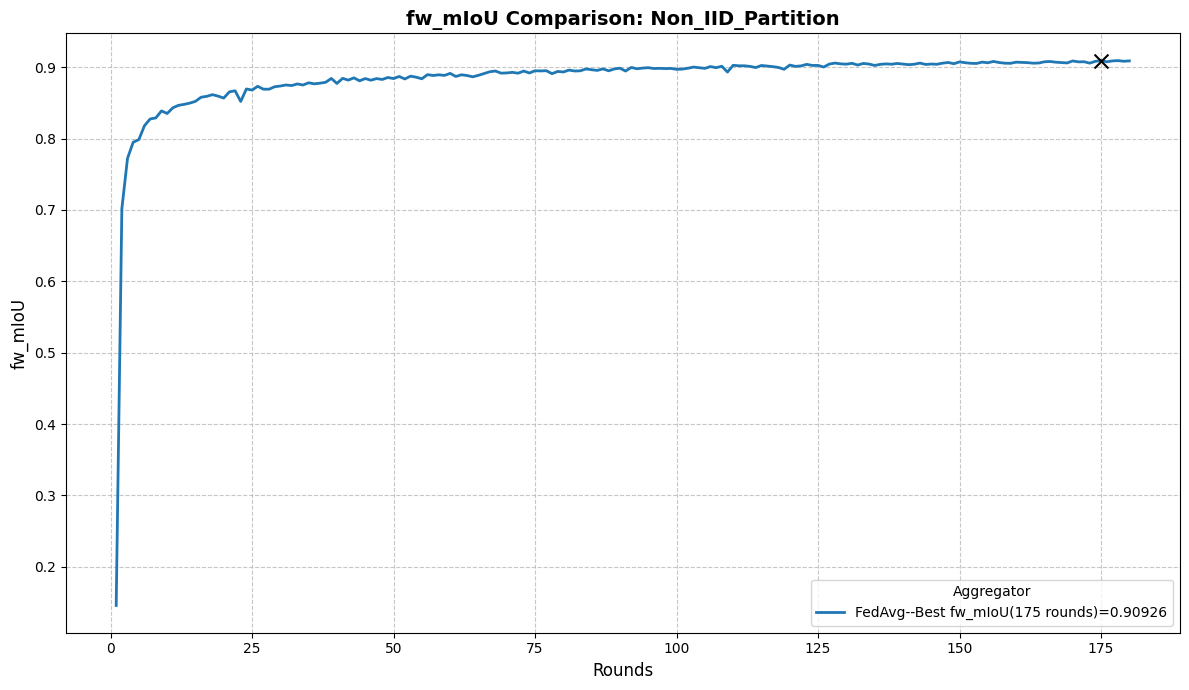

In [17]:
# run this cell to output combined plots per partation

# partation: City_Partitions,
#             IID_Partition, Non_IID_Partition
#             Per_City_IID, Per_City_Non_IID
partitions = ["IID_Partition",
              "Non_IID_Partition"]

# aggegator: FedAvg, FedProx
aggregators = ["FedAvg"]

# Trial number : First, Second, Third
trial_num = "New Partition Test (4th)"

# The metric you want to compare
target_metrics = ["mIoU", 'F1_Score', 'fw_mIoU']  #'mIoU', 'F1_Score', 'fw_mIoU'

# Loop through partitions and generate plots
for target_metric in target_metrics:
  print(f"Generating comparison plots for metric: {target_metric}...\n")

  for partition in partitions:
      print(f"Processing Partition: {partition}")

      plot_aggregator_comparison(
          partition_name=partition,
          aggregator_paths=aggregators,
          metric_name=target_metric,
          trial_num=trial_num
      )
      print("-" * 30)

  print("="*50)